# WDD Annotation Examination

Check that waggle dance annotations visually match the video frames for a selected video/annotation pair.

In [10]:
import ast
import base64
import subprocess
import tempfile
from pathlib import Path

import cv2
cv2.setNumThreads(1)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import HTML, display

DATA_DIR = Path("/remote/trove/imp/aglandgraf/wdd/wdd_videos_2025_sharoni")

VIDEO_PATH = DATA_DIR / "Capture_AG1_1_my_video-1-00.09.00.800-00.09.32.864-00.00.00.000-00.00.34.325-00.00.02.560-00.00.34.306.mkv"
ANN_PATH   = DATA_DIR / "Capture_AG1_1_my_video-1-00.09.00.800-00.09.32.864-00.00.00.000-00.00.34.325-00.00.02.560-00.00.34.306_waggle_annotations.csv"

print("video :", VIDEO_PATH.name)
print("annotation:", ANN_PATH.name)
print("video exists:", VIDEO_PATH.exists())
print("annotation exists:", ANN_PATH.exists())

video : Capture_AG1_1_my_video-1-00.09.00.800-00.09.32.864-00.00.00.000-00.00.34.325-00.00.02.560-00.00.34.306.mkv
annotation: Capture_AG1_1_my_video-1-00.09.00.800-00.09.32.864-00.00.00.000-00.00.34.325-00.00.02.560-00.00.34.306_waggle_annotations.csv
video exists: True
annotation exists: True


## Load & parse annotation

The CSV stores each dance as one row; coordinates and frame numbers are serialised Python lists.

In [11]:
def safe_eval(val):
    """Parse a stringified Python list/tuple, tolerating np.float64(...) wrappers."""
    if not isinstance(val, str) or not val.strip():
        return []
    # Replace np.float64(...) with the bare float so ast can parse it
    import re
    val = re.sub(r'np\.float64\(([^)]+)\)', r'\1', val)
    try:
        return ast.literal_eval(val)
    except Exception:
        return []


df = pd.read_csv(ANN_PATH)
print("columns:", list(df.columns))
print(f"rows (dances): {len(df)}\n")

list_cols = ["thorax_positions", "thorax_frames", "waggle_start_positions", "waggle_start_frames", "waggle_directions"]
for col in list_cols:
    df[col] = df[col].apply(safe_eval)

df.head()

columns: ['video_name', 'thorax_positions', 'thorax_frames', 'waggle_start_positions', 'waggle_start_frames', 'waggle_directions']
rows (dances): 1



,video_name,thorax_positions,thorax_frames,waggle_start_positions,waggle_start_frames,waggle_directions
0,/home/shafir-lab/Avi/Capture_AG1_1_my_video-1-...,"[(897, 1241), (862, 1238), (905, 1260), (934, ...","[82, 263, 415, 738, 1000, 1153, 1341, 1502, 17...","[(865, 1151), (868, 1148), (870, 1167), (881, ...","[25, 82, 193, 263, 357, 415, 662, 738, 960, 10...","[(0.0, 0.0), (0.18514836986616265, 0.982710578..."


## Annotation summary

In [12]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

all_waggle_frames = [f for row in df["waggle_start_frames"] for f in row]

print(f"video   : {width}x{height}  |  {fps:.2f} fps  |  {total_frames} frames  ({total_frames/fps:.1f} s)")
print(f"dances  : {len(df)}")
print(f"waggles : {len(all_waggle_frames)}")
print(f"frame range : {min(all_waggle_frames)} – {max(all_waggle_frames)}")
print()
for i, row in df.iterrows():
    frames = row["waggle_start_frames"]
    print(f"  dance {i}: {len(frames)//2} waggles, frames {frames[0] if frames else '?'} – {frames[-1] if frames else '?'}")

video   : 2448x2048  |  60.00 fps  |  1936 frames  (32.3 s)
dances  : 1
waggles : 20
frame range : 25 – 1893

  dance 0: 10 waggles, frames 25 – 1893


## Visualise annotated frames

For each dance, grab the frame at each waggle-start and draw the waggle position + direction arrow on it.

Dance 0, waggle 0: frames 25–82, pos=(865,1151)
Read 58 frames


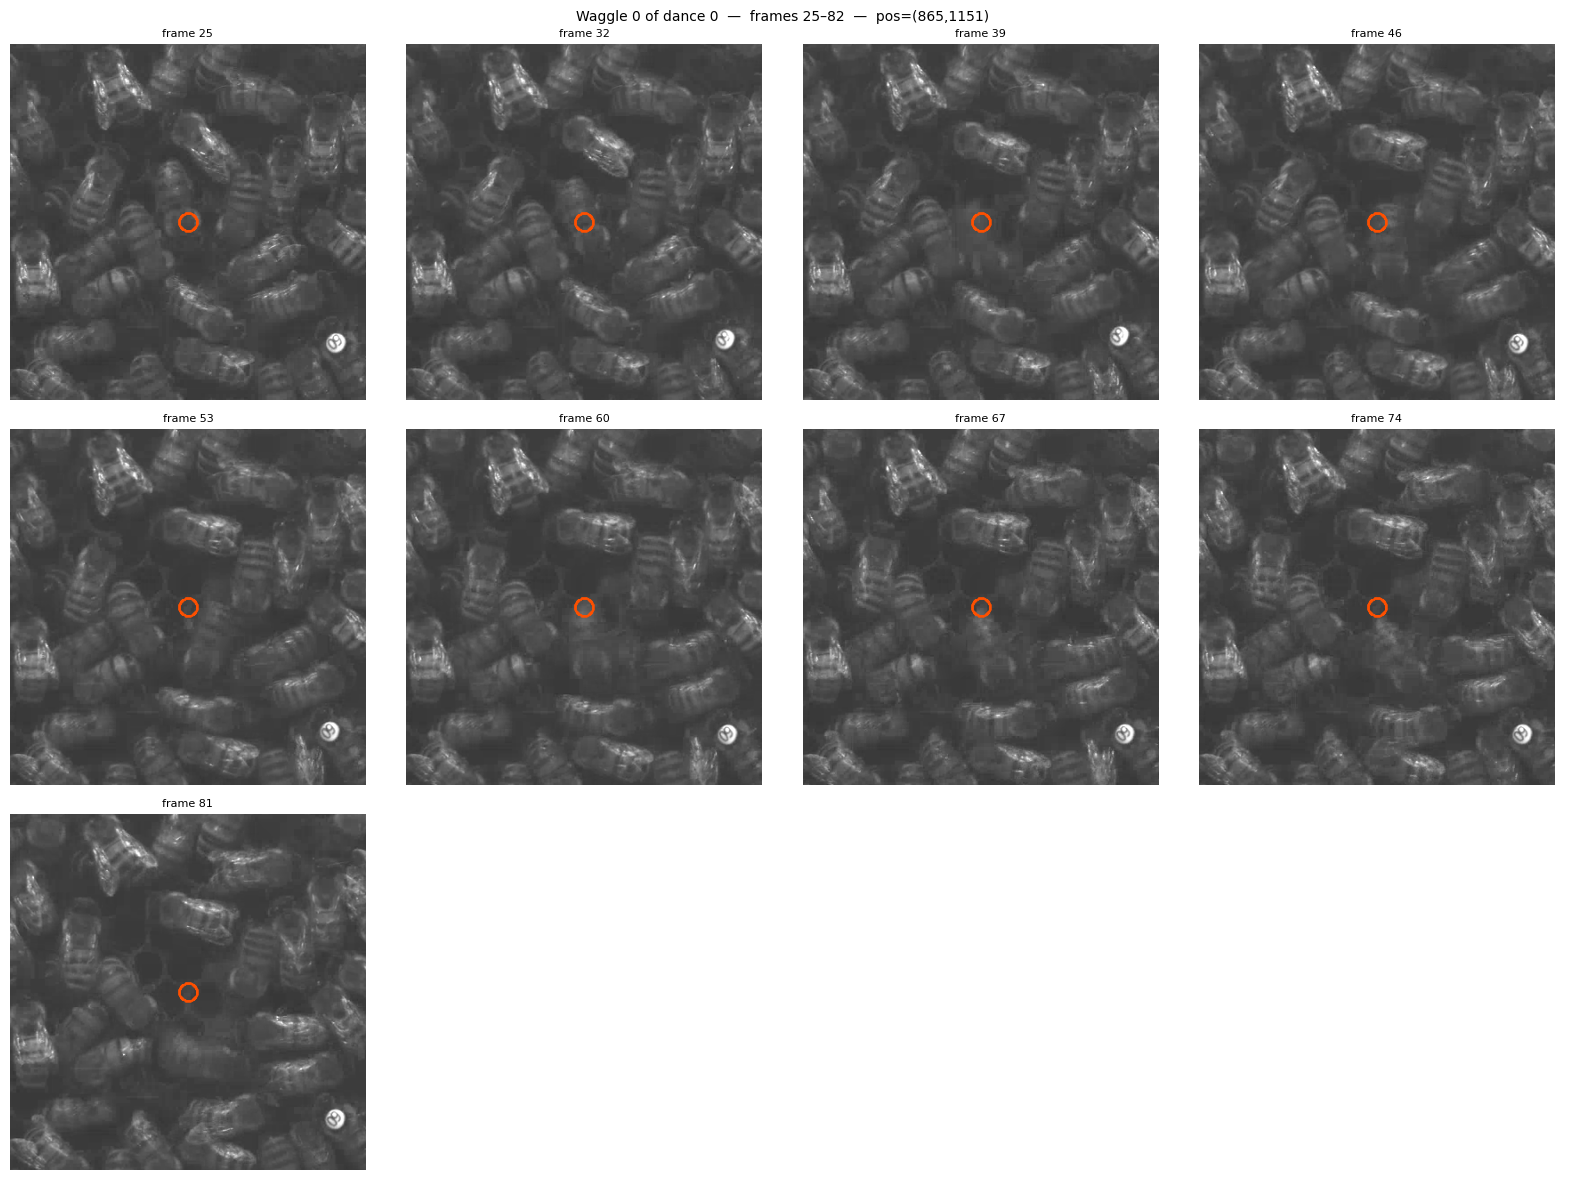

In [ ]:
DANCE_IDX  = 0
WAGGLE_IDX = 0   # which waggle within the dance

row   = df.iloc[DANCE_IDX]
# waggle_start_frames alternates [start_0, end_0, start_1, end_1, ...]
wf    = row["waggle_start_frames"]
wp    = row["waggle_start_positions"]

start_frame = wf[WAGGLE_IDX * 2]
end_frame   = wf[WAGGLE_IDX * 2 + 1]
waggle_pos  = wp[WAGGLE_IDX * 2]          # (x, y) at waggle start
x, y        = int(waggle_pos[0]), int(waggle_pos[1])

print(f"Dance {DANCE_IDX}, waggle {WAGGLE_IDX}: frames {start_frame}–{end_frame}, pos=({x},{y})")

# Read frames sequentially, one seek to start, then sequential reads
cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

frames = []
for _ in range(end_frame - start_frame + 1):
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

print(f"Read {len(frames)} frames")

# Show every nth frame in a grid with annotation overlay
STEP = max(1, len(frames) // 8)   # show approx 8 thumbnails
CROP = 200
COLS = 4

selected = frames[::STEP]
rows_needed = (len(selected) + COLS - 1) // COLS
fig, axes = plt.subplots(rows_needed, COLS, figsize=(COLS * 4, rows_needed * 4))
axes = np.array(axes).reshape(-1)

for i, f in enumerate(selected):
    x0, x1 = max(0, x - CROP), min(f.shape[1], x + CROP)
    y0, y1 = max(0, y - CROP), min(f.shape[0], y + CROP)
    crop = f[y0:y1, x0:x1].copy()
    cx, cy = x - x0, y - y0
    cv2.circle(crop, (cx, cy), 10, (255, 80, 0), 2)
    axes[i].imshow(crop)
    axes[i].set_title(f"frame {start_frame + i * STEP}", fontsize=8)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Waggle {WAGGLE_IDX} of dance {DANCE_IDX}  —  frames {start_frame}–{end_frame}  —  pos=({x},{y})", fontsize=10)
plt.tight_layout()
plt.show()

## Waggle run as inline video

In [14]:
def frames_to_html_video(frames, fps, crop_box=None, annotation_pos=None):
    """
    Write `frames` (list of RGB numpy arrays) to a browser-playable mp4.

    crop_box       : (x0, y0, x1, y1) with an optional crop applied to every frame
    annotation_pos : (x, y) in the final frame coordinates which draws a circle
    """
    if not frames:
        return HTML("<p>no frames</p>")

    if crop_box:
        x0, y0, x1, y1 = crop_box
        w, h = x1 - x0, y1 - y0
    else:
        h, w = frames[0].shape[:2]

    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
        raw_path = tmp.name

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(raw_path, fourcc, fps, (w, h))

    for f in frames:
        bgr = cv2.cvtColor(f, cv2.COLOR_RGB2BGR)
        if crop_box:
            bgr = bgr[y0:y1, x0:x1]
        if annotation_pos:
            cv2.circle(bgr, annotation_pos, 20, (0, 80, 255), 3)
        out.write(bgr)
    out.release()

    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp2:
        final_path = tmp2.name
    subprocess.run(
        ["ffmpeg", "-y", "-threads", "1", "-i", raw_path,
         "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-preset", "fast", final_path],
        capture_output=True, check=True
    )
    Path(raw_path).unlink(missing_ok=True)

    data = base64.b64encode(Path(final_path).read_bytes()).decode()
    Path(final_path).unlink(missing_ok=True)

    return HTML(f'<video controls loop width="100%">'
                f'<source src="data:video/mp4;base64,{data}" type="video/mp4">'
                f'</video>')


# full resolution with annotation dot at the waggle position in the original frame
display(frames_to_html_video(frames, fps, annotation_pos=(x, y)))

CalledProcessError: Command '['ffmpeg', '-y', '-threads', '1', '-i', '/tmp/tmpb6t26ghp.mp4', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-preset', 'fast', '/tmp/tmp0g6yv7ij.mp4']' returned non-zero exit status 187.